<a href="https://colab.research.google.com/github/WooSeungJi/WM811K-Project/blob/main/%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D_WM_811K_Wafer_Map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive

drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os

os.listdir('/content/drive/MyDrive')

['bugreport-NRD90U-2019-11-14-16-04-22.zip',
 'bugreport-NRD90U-2019-11-14-16-04-22.png',
 'Classroom',
 'Google AI Studio',
 'Colab Notebooks',
 '25-2 반도체공학 Assignment.gdoc',
 '머신러닝 4. Machine Learning Pipeline - 실습.ipynb',
 'ML Project',
 'ML_Project']

In [5]:
import os

print(os.listdir('/content/drive/MyDrive/ML Project'))

['WM811K']


In [6]:
print(os.listdir('/content/drive/MyDrive/ML Project/WM811K'))

['LSWMD.pkl']


In [7]:
import pandas as pd
import numpy as np
import os

file_path = "/content/drive/MyDrive/ML Project/WM811K/LSWMD.pkl"

df = pd.read_pickle(file_path)

print("데이터 로드 완료")
print("데이터 크기:", df.shape)
df.head()

데이터 로드 완료
데이터 크기: (811457, 6)


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


#**현재 failureType을 보면 [[none]]으로 들어가 있다.**
**그래서 그냥 문자열이 아니라, 안쪽에 들어있는 값을 꺼내야 한다.**


In [8]:
print(df.columns)

Index(['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel',
       'failureType'],
      dtype='object')


In [9]:
# 라벨 추출 진행
# failureType
def get_label(x):
    try:
        return x[0][0]
    except:
        return 'unknown'

df['label'] = df['failureType'].apply(get_label)

print("라벨 종류:")
print(df['label'].unique())

print("\n클래스별 개수:")
print(df['label'].value_counts())

라벨 종류:
[np.str_('none') np.str_('Loc') 'unknown' np.str_('Edge-Loc')
 np.str_('Center') np.str_('Edge-Ring') np.str_('Scratch')
 np.str_('Random') np.str_('Near-full') np.str_('Donut')]

클래스별 개수:
label
unknown      638507
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


#**이를 통해 전체 데이터 중 상당수는 결함 라벨이 없는 데이터임을 알 수 있다.**
여기서 unknown은 내가 직접 만든 라벨이다.


In [10]:
df_labeled = df[df['label'] != 'unknown'].copy()

print("전체 데이터 크기:", df.shape)
print("라벨 있는 데이터 크기:", df_labeled.shape)

print("\n라벨 있는 데이터의 클래스별 개수:")
print(df_labeled['label'].value_counts())

전체 데이터 크기: (811457, 7)
라벨 있는 데이터 크기: (172950, 7)

라벨 있는 데이터의 클래스별 개수:
label
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


In [11]:
label_count = df_labeled['label'].value_counts()
label_ratio = df_labeled['label'].value_counts(normalize=True) * 100

class_summary = pd.DataFrame({
    "count": label_count,
    "ratio(%)": label_ratio.round(2)
})

class_summary

,count,ratio(%)
label,,
none,147431,85.24
Edge-Ring,9680,5.60
Edge-Loc,5189,3.00
Center,4294,2.48
Loc,3593,2.08
Scratch,1193,0.69
Random,866,0.50
Donut,555,0.32
Near-full,149,0.09


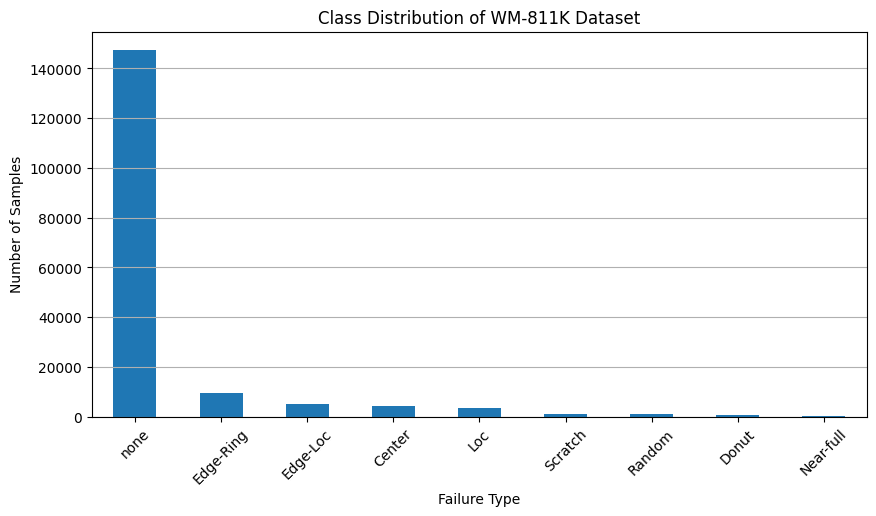

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
label_count.plot(kind='bar')
plt.title("Class Distribution of WM-811K Dataset")
plt.xlabel("Failure Type")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

# **none 클래스가 압도적으로 많다.**
따라서 만약 만들어진 모델이 대부분을 none으로 예측을 하더라도 정확도가 높아 보이는 오류가 발생할 수 있다.
# **클래스 불균형 처리가 필요하다.**

1. Train / Validation / Test 먼저 분리 **
2. Validation / Test는 원본 분포 그대로 유지
3. Train 데이터에만 클래스 불균형 처리 적용
4. CNN에는 회전/반전 기반 데이터 증강 적용
5. CNN 학습 시 class_weight 적용
6. Random Forest에는 class_weight='balanced' 적용
7. 최종 평가는 Accuracy보다 Macro F1, Recall, Confusion Matrix 중심으로 해석


CNN:
- None 클래스는 증강하지 않음
- 소수 클래스만 회전/반전 증강
- 각 클래스 최대 목표 개수를 5,000장 또는 10,000장으로 제한
- class_weight 함께 적용

Random Forest:
- 데이터 증강보다는 class_weight='balanced' 적용
- Feature Engineering 결과에 대해 불균형 보정

**본 프로젝트에서는 WM-811K 데이터셋의 극심한 클래스 불균형 문제를 완화하기 위해 데이터 증강과 클래스 가중치 적용을 함께 사용하였다. 기존 연구에서는 None 클래스를 기준으로 소수 클래스를 25%, 50%, 100% 수준까지 증강하여 성능 변화를 비교하였으나, 본 프로젝트에서는 계산 자원과 과도한 증강으로 인한 과적합 가능성을 고려하여 모든 클래스를 None 클래스와 동일한 개수로 맞추지는 않았다.**

**대신 train 데이터에 대해서만 소수 클래스를 제한된 목표 개수까지 회전 및 반전 기반으로 증강하고, 모델 학습 과정에서는 클래스 가중치를 적용하여 소수 클래스의 오분류 손실이 더 크게 반영되도록 하였다. Validation과 Test 데이터는 원본 클래스 분포를 유지하여 실제 불균형 환경에서의 모델 성능을 평가하였다.**

## **1. 클래스 불균형 분석 코드**

In [13]:
# ============================================================
# 0. 필요한 라이브러리 불러오기
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, recall_score

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping


# ============================================================
# 1. label 컬럼 확인 및 생성
# ============================================================

# 현재 df_labeled에 label 컬럼이 이미 있으면 그대로 사용한다.
# 만약 label 컬럼이 없다면, failureType에서 라벨을 추출해서 label 컬럼을 만든다.

if 'label' not in df_labeled.columns:
    def extract_label(x):
        # WM-811K의 failureType은 보통 array 형태로 들어있다.
        # 예: [[none]], [[Center]] 같은 구조
        try:
            return x[0][0]
        except:
            return None

    df_labeled['label'] = df_labeled['failureType'].apply(extract_label)

# 혹시 label이 비어 있는 데이터가 남아 있다면 제거한다.
df_labeled = df_labeled[df_labeled['label'].notna()].copy()

# unknown 라벨이 있다면 제거한다.
df_labeled = df_labeled[df_labeled['label'] != 'unknown'].copy()

print("라벨링 데이터 개수:", len(df_labeled))
print()
print("클래스 분포:")
print(df_labeled['label'].value_counts())

라벨링 데이터 개수: 172950

클래스 분포:
label
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


## **2. 클래스 분포 시각화**

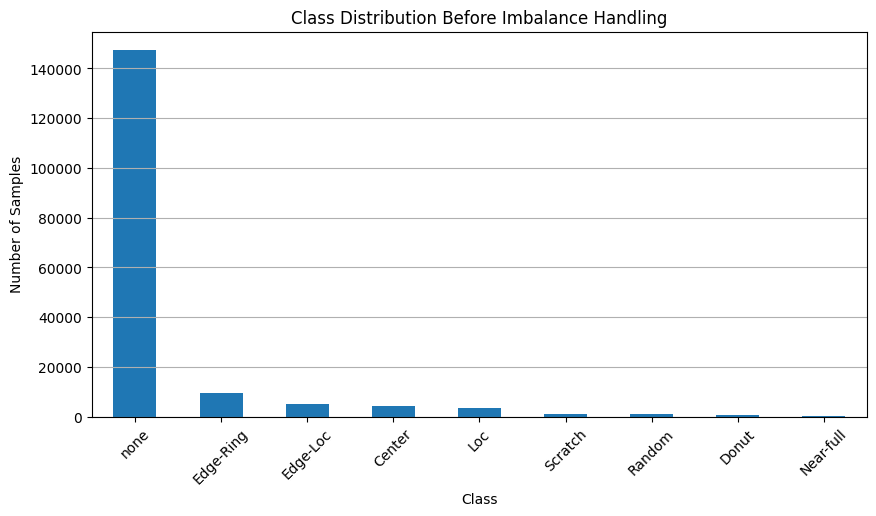

In [14]:
# ============================================================
# 2. 클래스 분포 시각화
# ============================================================

label_count = df_labeled['label'].value_counts()

plt.figure(figsize=(10, 5))
label_count.plot(kind='bar')
plt.title("Class Distribution Before Imbalance Handling")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

## **3. Train / Validation / Test 분리**

In [15]:
# ============================================================
# 3. Train / Validation / Test Split
# ============================================================

# 1차 분리: train 60%, temp 40%
df_train, df_temp = train_test_split(
    df_labeled,
    test_size=0.4,
    random_state=42,
    stratify=df_labeled['label']
)

# 2차 분리: validation 20%, test 20%
df_val, df_test = train_test_split(
    df_temp,
    test_size=0.5,
    random_state=42,
    stratify=df_temp['label']
)

print("Train size:", len(df_train))
print("Validation size:", len(df_val))
print("Test size:", len(df_test))

print("\nTrain class distribution")
print(df_train['label'].value_counts())

print("\nValidation class distribution")
print(df_val['label'].value_counts())

print("\nTest class distribution")
print(df_test['label'].value_counts())

Train size: 103770
Validation size: 34590
Test size: 34590

Train class distribution
label
none         88459
Edge-Ring     5808
Edge-Loc      3113
Center        2576
Loc           2156
Scratch        716
Random         520
Donut          333
Near-full       89
Name: count, dtype: int64

Validation class distribution
label
none         29486
Edge-Ring     1936
Edge-Loc      1038
Center         859
Loc            718
Scratch        239
Random         173
Donut          111
Near-full       30
Name: count, dtype: int64

Test class distribution
label
none         29486
Edge-Ring     1936
Edge-Loc      1038
Center         859
Loc            719
Scratch        238
Random         173
Donut          111
Near-full       30
Name: count, dtype: int64


## **4. Label Encoding**
CNN은 문자 라벨이 아니라 숫자 라벨을 사용해야 하므로 라벨을 숫자로 바꾼다.

In [16]:
# ============================================================
# 4. Label Encoding
# ============================================================

le = LabelEncoder()

df_train = df_train.copy()
df_val = df_val.copy()
df_test = df_test.copy()

df_train['label_encoded'] = le.fit_transform(df_train['label'])
df_val['label_encoded'] = le.transform(df_val['label'])
df_test['label_encoded'] = le.transform(df_test['label'])

print("클래스 순서:")
for idx, class_name in enumerate(le.classes_):
    print(idx, ":", class_name)

클래스 순서:
0 : Center
1 : Donut
2 : Edge-Loc
3 : Edge-Ring
4 : Loc
5 : Near-full
6 : Random
7 : Scratch
8 : none


## **5. Wafer Map Resize 함수**
Wafer Map은 일반 사진이 아니라 0, 1, 2 같은 die 상태값이므로, resize할 때 INTER_NEAREST를 사용한다.

In [17]:
# ============================================================
# 5. Wafer Map Resize 함수
# ============================================================

def resize_wafer_map(wafer_map, size=(64, 64)):
    """
    wafer_map을 64 x 64 크기로 변환하는 함수이다.

    중요한 점:
    Wafer Map은 일반 이미지가 아니라 die 상태를 나타내는 배열이다.
    따라서 bilinear interpolation을 쓰면 0.3, 1.7 같은 의미 없는 값이 생길 수 있다.
    그래서 nearest interpolation을 사용한다.
    """

    wafer_map = np.array(wafer_map)

    resized = cv2.resize(
        wafer_map,
        size,
        interpolation=cv2.INTER_NEAREST
    )

    return resized

## **6. 데이터 증강 함수**
여기서는 회전과 반전만 사용한다.

밝기 조절, 색상 변환, random crop은 사용하지 않는다.

In [18]:
# ============================================================
# 6. Wafer Map 데이터 증강 함수
# ============================================================

def augment_wafer_map(wafer_map):
    """
    하나의 wafer map에 대해 여러 개의 증강 이미지를 생성한다.

    적용하는 증강:
    1. 90도 회전
    2. 180도 회전
    3. 270도 회전
    4. 좌우 반전
    5. 상하 반전

    Wafer Map은 원형 구조이기 때문에 회전/반전은 패턴 의미를 비교적 잘 유지한다.
    """

    augmented_images = []

    wafer_map = np.array(wafer_map)

    # 90도 회전
    augmented_images.append(np.rot90(wafer_map, k=1))

    # 180도 회전
    augmented_images.append(np.rot90(wafer_map, k=2))

    # 270도 회전
    augmented_images.append(np.rot90(wafer_map, k=3))

    # 좌우 반전
    augmented_images.append(np.fliplr(wafer_map))

    # 상하 반전
    augmented_images.append(np.flipud(wafer_map))

    return augmented_images

## **7. Train 데이터에만 제한적 증강 적용**
None 클래스는 증강하지 않음
소수 클래스만 target_count까지 증강
이미 target_count보다 많은 클래스는 증강하지 않음
Validation/Test는 절대 증강하지 않음

In [19]:
# ============================================================
# 7. Train 데이터에만 제한적 증강 적용
# ============================================================

target_count = 5000

augmented_rows = []

train_class_counts = df_train['label'].value_counts()

print("증강 전 Train 클래스 분포")
print(train_class_counts)

for class_name in le.classes_:

    # None 클래스는 증강하지 않는다.
    if class_name == 'none' or class_name == 'None':
        print(f"{class_name}: None 클래스이므로 증강하지 않음")
        continue

    class_df = df_train[df_train['label'] == class_name]
    current_count = len(class_df)

    # 이미 target_count 이상이면 증강하지 않는다.
    if current_count >= target_count:
        print(f"{class_name}: 현재 {current_count}개 → target_count 이상이므로 증강하지 않음")
        continue

    need_count = target_count - current_count

    print(f"{class_name}: 현재 {current_count}개 → {need_count}개 증강 필요")

    generated_count = 0

    # class_df를 반복하면서 필요한 개수만큼 증강 데이터를 만든다.
    while generated_count < need_count:

        for _, row in class_df.iterrows():

            if generated_count >= need_count:
                break

            wafer_map = row['waferMap']
            label = row['label']
            label_encoded = row['label_encoded']

            aug_images = augment_wafer_map(wafer_map)

            for aug_img in aug_images:

                if generated_count >= need_count:
                    break

                augmented_rows.append({
                    'waferMap': aug_img,
                    'label': label,
                    'label_encoded': label_encoded
                })

                generated_count += 1

print("\n생성된 증강 데이터 개수:", len(augmented_rows))

df_augmented = pd.DataFrame(augmented_rows)

# 원본 train 데이터와 증강 데이터를 합친다.
df_train_balanced = pd.concat(
    [
        df_train[['waferMap', 'label', 'label_encoded']],
        df_augmented
    ],
    axis=0
).reset_index(drop=True)

print("\n증강 후 Train 클래스 분포")
print(df_train_balanced['label'].value_counts())

증강 전 Train 클래스 분포
label
none         88459
Edge-Ring     5808
Edge-Loc      3113
Center        2576
Loc           2156
Scratch        716
Random         520
Donut          333
Near-full       89
Name: count, dtype: int64
Center: 현재 2576개 → 2424개 증강 필요
Donut: 현재 333개 → 4667개 증강 필요
Edge-Loc: 현재 3113개 → 1887개 증강 필요
Edge-Ring: 현재 5808개 → target_count 이상이므로 증강하지 않음
Loc: 현재 2156개 → 2844개 증강 필요
Near-full: 현재 89개 → 4911개 증강 필요
Random: 현재 520개 → 4480개 증강 필요
Scratch: 현재 716개 → 4284개 증강 필요
none: None 클래스이므로 증강하지 않음

생성된 증강 데이터 개수: 25497

증강 후 Train 클래스 분포
label
none         88459
Edge-Ring     5808
Loc           5000
Center        5000
Edge-Loc      5000
Scratch       5000
Near-full     5000
Random        5000
Donut         5000
Name: count, dtype: int64


## **8. 증강 후 클래스 분포 시각화**


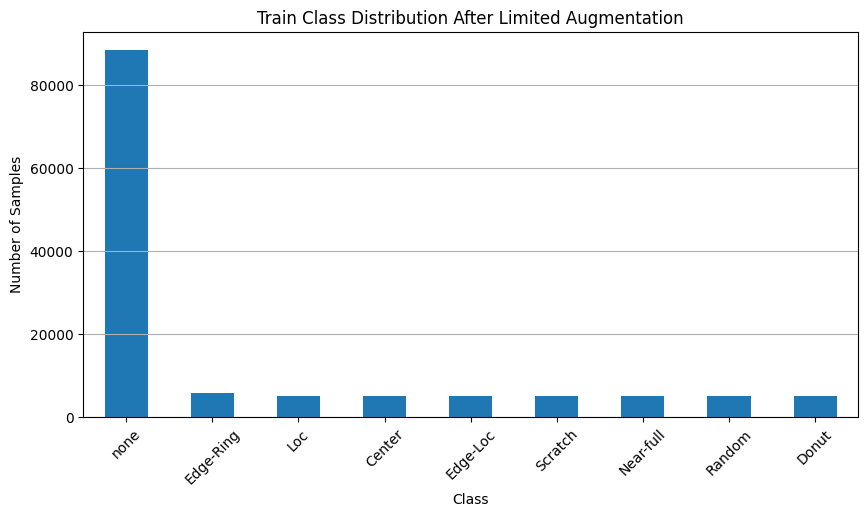

In [20]:
# ============================================================
# 8. 증강 후 클래스 분포 시각화
# ============================================================

plt.figure(figsize=(10, 5))
df_train_balanced['label'].value_counts().plot(kind='bar')
plt.title("Train Class Distribution After Limited Augmentation")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

## **9. CNN 입력 데이터 생성 함수**


In [21]:
# ============================================================
# 9. CNN 입력 데이터 생성 함수
# ============================================================

def make_cnn_dataset(df):
    """
    dataframe을 CNN 입력 형태로 변환한다.

    입력:
    df['waferMap']
    df['label_encoded']

    출력:
    X shape: (데이터 수, 64, 64, 1)
    y shape: (데이터 수,)
    """

    X = []
    y = []

    for _, row in df.iterrows():

        img = resize_wafer_map(row['waferMap'], size=(64, 64))

        X.append(img)
        y.append(row['label_encoded'])

    X = np.array(X)
    y = np.array(y)

    # CNN 입력 형태로 변경
    X = X.reshape(-1, 64, 64, 1)

    # wafer map 값이 보통 0, 1, 2이므로 2로 나누어 0~1 범위로 정규화한다.
    X = X.astype('float32') / 2.0

    return X, y

## **10. CNN 데이터셋 만들기**


In [22]:
# ============================================================
# 10. CNN 데이터셋 만들기
# ============================================================

X_train, y_train = make_cnn_dataset(df_train_balanced)
X_val, y_val = make_cnn_dataset(df_val)
X_test, y_test = make_cnn_dataset(df_test)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (129267, 64, 64, 1)
y_train: (129267,)
X_val: (34590, 64, 64, 1)
y_val: (34590,)
X_test: (34590, 64, 64, 1)
y_test: (34590,)


## **11. 클래스 가중치 계산**


In [23]:
# ============================================================
# 11. 클래스 가중치 계산
# ============================================================

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))

print("Class Weight")
for class_idx, weight in class_weight_dict.items():
    print(le.classes_[class_idx], ":", weight)

Class Weight
Center : 2.8726
Donut : 2.8726
Edge-Loc : 2.8726
Edge-Ring : 2.4729683195592287
Loc : 2.8726
Near-full : 2.8726
Random : 2.8726
Scratch : 2.8726
none : 0.1623690071106388


## **12. TensorFlow Dataset 구성**


In [24]:
# ============================================================
# 12. TensorFlow Dataset 구성
# ============================================================

batch_size = 64

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(10000)
train_ds = train_ds.batch(batch_size)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.batch(batch_size)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.batch(batch_size)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

## **13. Simple CNN 모델 정의**


In [25]:
# ============================================================
# 13. Simple CNN 모델 정의
# ============================================================

num_classes = len(le.classes_)

model = models.Sequential([
    layers.Input(shape=(64, 64, 1)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,537 (4.36 MB)

 Trainable params: 1,142,537 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

## **14. 모델 학습**


In [ ]:
# ============================================================
# 14. 모델 학습
# ============================================================

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os

# 모델 저장 폴더
save_dir = "/content/drive/MyDrive/ML_Project/WM811K/processed"
os.makedirs(save_dir, exist_ok=True)

# 가장 좋은 모델을 저장할 경로
checkpoint_path = os.path.join(save_dir, "simple_cnn_best.keras")

# validation loss가 5번 연속 좋아지지 않으면 학습 중단
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# validation loss가 가장 좋은 모델을 Google Drive에 저장
checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

# 모델 학습
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weight_dict,
    callbacks=[early_stop, checkpoint]
)

print("학습 완료")
print("Best model saved at:", checkpoint_path)

Epoch 1/30


## **15. 학습 과정 시각화**
